<a href="https://colab.research.google.com/github/talmolab/sleap/blob/main/docs/notebooks/Interactive_and_realtime_inference.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Interactive and realtime inference

For most workflows, using the [`sleap-track` CLI](../../reference/command-line-interfaces/#sleap-track) or [`sleap-nn track` CLI](https://nn.sleap.ai/latest/inference) is probably the most convenient option, but if you're developing a custom application you can take advantage of SLEAP's inference API to use your trained models in your own custom scripts.

In this notebook we will explore how to predict poses from raw images in pure Python, and do some basic benchmarking on a simulated realtime predictor that could be used to enable closed-loop experiments.

## 1. Setup

Run this cell first to install sleap-nn. If you get a dependency error in subsequent cells, just click **Runtime** → **Restart runtime** to reload the packages.

Don't forget to set **Runtime** → **Change runtime type** → **GPU** as the accelerator.

In [1]:
# This should take care of all the dependencies on colab:
!pip install -qqq "sleap-io"
!pip install -qqq "sleap-nn[torch-cpu]"

zsh:1: command not found: pip
zsh:1: command not found: pip


Import SLEAP to make sure it installed correctly and print out some information about the system:

In [2]:
import sleap_nn

sleap_nn.__version__

'0.0.1'

## 2. Setup data

Before we start, let's download a raw video and a set of trained top-down ID models that we'll use to build our application around.

In [3]:
!curl -L --output video.mp4 https://storage.googleapis.com/sleap-data/reference/flies13/190719_090330_wt_18159206_rig1.2%4015000-17560.mp4
!curl -L --output centroid_model.zip https://storage.googleapis.com/sleap-data/reference/flies13/centroid.fast.210504_182918.centroid.n%3D1800.zip
!curl -L --output centered_instance_id_model.zip https://storage.googleapis.com/sleap-data/reference/flies13/td_id.fast.v2.210519_111253.multi_class_topdown.n%3D1800.zip
!ls -lah

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 81.3M  100 81.3M    0     0  29.9M      0  0:00:02  0:00:02 --:--:-- 29.9M
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 6223k  100 6223k    0     0  6951k      0 --:--:-- --:--:-- --:--:-- 6945k
  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 32.2M  100 32.2M    0     0  19.9M      0  0:00:01  0:00:01 --:--:-- 19.8M1k      0  0:00:33 --:--:--  0:00:33  990k
total 281544
drwxr-xr-x@ 16 divyasesh  staff   512B Sep 25 10:57 .
drwxr-xr-x@ 15 divyasesh  staff   480B Sep 24 17:10 ..
-rw-r--r--@  1 divyasesh  staff   713K Sep 22 10:30 Analysis_examples.ipynb
-rw-r--r--@  1 divyasesh  staff   462K Sep 22 12:

**Note:** These zip files just have the contents of standard SLEAP model folders that are generated during training.

In [4]:
!unzip centroid_model.zip -d centroid_model
!unzip centered_instance_id_model.zip -d centered_instance_id_model


Archive:  centroid_model.zip
  inflating: centroid_model/best_model.h5  
  inflating: centroid_model/initial_config.json  
  inflating: centroid_model/labels_gt.test.slp  
  inflating: centroid_model/labels_gt.train.slp  
  inflating: centroid_model/labels_gt.val.slp  
  inflating: centroid_model/labels_pr.test.slp  
  inflating: centroid_model/labels_pr.train.slp  
  inflating: centroid_model/labels_pr.val.slp  
 extracting: centroid_model/metrics.test.npz  
  inflating: centroid_model/metrics.train.npz  
  inflating: centroid_model/metrics.val.npz  
  inflating: centroid_model/model_info.json  
  inflating: centroid_model/training_config.json  
  inflating: centroid_model/training_log.csv  
Archive:  centered_instance_id_model.zip
   creating: centered_instance_id_model/savedmodel
   creating: centered_instance_id_model/savedmodel/variables
  inflating: centered_instance_id_model/savedmodel/variables/variables.index  
  inflating: centered_instance_id_model/savedmodel/variables/varia

## 3. Interactive inference

SLEAP provides a high-level API for performing inference: `run_inference`.

We'll load a video that we want to use for inference. SLEAP `Video` objects don't actually load the whole video into memory, they just provide a common numpy-like interface for reading from different file formats:

In [3]:
import sleap_io as sio
video = sio.load_video("video.mp4")
video.shape, type(video)

((2560, 1024, 1024, 1), sleap_io.model.video.Video)

In [4]:
from sleap_nn.predict import run_inference

predictions = run_inference(input_video=video, model_paths=["centroid_model", "centered_instance_id_model"], output_path="predictions.slp", integral_refinement=None)

2025-09-25 15:32:51 | INFO | sleap_nn.predict:run_inference:319 | Started inference at: 2025-09-25 15:32:51.399249
2025-09-25 15:32:51 | INFO | sleap_nn.predict:run_inference:335 | Using device: mps
2025-09-25 15:32:51 | INFO | sleap_nn.legacy_models:get_keras_first_layer_channels:57 | Found first layer 'model_weights/stack0_enc0_conv0/stack0_enc0_conv0/kernel:0' with 1 input channels
2025-09-25 15:32:51 | INFO | sleap_nn.legacy_models:map_legacy_to_pytorch_layers:272 | Successfully mapped 34/34 legacy weights to PyTorch parameters
2025-09-25 15:32:51 | INFO | sleap_nn.legacy_models:load_legacy_model_weights:365 | Successfully loaded 34/34 weights from legacy model
2025-09-25 15:32:51 | INFO | sleap_nn.legacy_models:load_legacy_model_weights:376 | Verifying weight assignments...
2025-09-25 15:32:51 | INFO | sleap_nn.legacy_models:load_legacy_model_weights:437 | ✓ All weight assignments verified successfully


Output()

2025-09-25 15:32:51 | INFO | sleap_nn.legacy_models:get_keras_first_layer_channels:57 | Found first layer 'model_weights/stack0_enc0_conv0/stack0_enc0_conv0/kernel:0' with 1 input channels
2025-09-25 15:32:51 | INFO | sleap_nn.legacy_models:map_legacy_to_pytorch_layers:272 | Successfully mapped 34/34 legacy weights to PyTorch parameters
2025-09-25 15:32:51 | INFO | sleap_nn.legacy_models:load_legacy_model_weights:365 | Successfully loaded 34/34 weights from legacy model
2025-09-25 15:32:51 | INFO | sleap_nn.legacy_models:load_legacy_model_weights:376 | Verifying weight assignments...
2025-09-25 15:32:51 | INFO | sleap_nn.legacy_models:load_legacy_model_weights:437 | ✓ All weight assignments verified successfully
2025-09-25 15:32:51 | INFO | sleap_nn.legacy_models:get_keras_first_layer_channels:57 | Found first layer 'model_weights/stack0_enc0_conv0/stack0_enc0_conv0/kernel:0' with 1 input channels
2025-09-25 15:32:51 | INFO | sleap_nn.legacy_models:map_legacy_to_pytorch_layers:272 | Su

2025-09-25 15:33:56 | INFO | sleap_nn.predict:run_inference:453 | Finished inference at: 2025-09-25 15:33:56.836492
2025-09-25 15:33:56 | INFO | sleap_nn.predict:run_inference:454 | Total runtime: 65.43725609779358 secs
2025-09-25 15:33:57 | INFO | sleap_nn.predict:run_inference:465 | Predictions output path: predictions.slp
2025-09-25 15:33:57 | INFO | sleap_nn.predict:run_inference:466 | Saved file at: 2025-09-25 15:33:57.130979


This function handles all the logic of loading trained models, reading the configurations used to train them, and constructs inference models that also include non-trainable operations like peak finding and instance grouping.

Our predictor is pretty flexible. It can take in either a data path, or a Labels object or a Video object, all of which will return a `Labels` object that contains all of our predictions:

We can then inspect the results of our predictor:

In [5]:
import seaborn as sns
from typing import Union, Tuple
import matplotlib.pyplot as plt
import numpy as np
import matplotlib

def imgfig(
    size: Union[float, Tuple] = 6, dpi: int = 72, scale: float = 1.0
) -> matplotlib.figure.Figure:
    """Create a tight figure for image plotting.

    Args:
        size: Scalar or 2-tuple specifying the (width, height) of the figure in inches.
            If scalar, will assume equal width and height.
        dpi: Dots per inch, controlling the resolution of the image.
        scale: Factor to scale the size of the figure by. This is a convenience for
            increasing the size of the plot at the same DPI.

    Returns:
        A matplotlib.figure.Figure to use for plotting.
    """
    if not isinstance(size, (tuple, list)):
        size = (size, size)
    fig = plt.figure(figsize=(scale * size[0], scale * size[1]), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1], frameon=False)
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
    plt.autoscale(tight=True)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(False)
    return fig

def plot_img(
    img: np.ndarray, dpi: int = 72, scale: float = 1.0
) -> matplotlib.figure.Figure:
    """Plot an image in a tight figure."""
    if hasattr(img, "numpy"):
        img = img.numpy()

    if img.shape[0] == 1:
        # Squeeze out batch singleton dimension.
        img = img.squeeze(axis=0)

    # Check if image is grayscale (single channel).
    grayscale = img.shape[-1] == 1
    if grayscale:
        # Squeeze out singleton channel.
        img = img.squeeze(axis=-1)

    # Normalize the range of pixel values.
    img_min = img.min()
    img_max = img.max()
    if img_min < 0.0 or img_max > 1.0:
        img = (img - img_min) / (img_max - img_min)

    fig = imgfig(
        size=(float(img.shape[1]) / dpi, float(img.shape[0]) / dpi),
        dpi=dpi,
        scale=scale,
    )

    ax = fig.gca()
    ax.imshow(
        img,
        cmap="gray" if grayscale else None,
        origin="upper",
        extent=[-0.5, img.shape[1] - 0.5, img.shape[0] - 0.5, -0.5],
    )
    return fig

def plot_instance(
    instance,
    skeleton=None,
    cmap=None,
    color_by_node=False,
    lw=2,
    ms=10,
    bbox=None,
    scale=1.0,
    **kwargs,
):
    """Plot a single instance with edge coloring."""
    if cmap is None:
        cmap = sns.color_palette("tab20")

    if skeleton is None and hasattr(instance, "skeleton"):
        skeleton = instance.skeleton

    if skeleton is None:
        color_by_node = True
    else:
        if len(skeleton.edges) == 0:
            color_by_node = True

    if hasattr(instance, "numpy"):
        inst_pts = instance.numpy()
    else:
        inst_pts = instance

    h_lines = []
    if color_by_node:
        for k, (x, y) in enumerate(inst_pts):
            if bbox is not None:
                x -= bbox[1]
                y -= bbox[0]

            x *= scale
            y *= scale

            h_lines_k = plt.plot(x, y, ".", ms=ms, c=cmap[k % len(cmap)], **kwargs)
            h_lines.append(h_lines_k)

    else:
        for k, (src_node, dst_node) in enumerate(skeleton.edges):
            pts = instance.numpy()
            src_pt = pts[skeleton.node_names.index(src_node.name)]
            dst_pt = pts[skeleton.node_names.index(dst_node.name)]

            x = np.array([src_pt[0], dst_pt[0]])
            y = np.array([src_pt[1], dst_pt[1]])

            if bbox is not None:
                x -= bbox[1]
                y -= bbox[0]

            x *= scale
            y *= scale

            h_lines_k = plt.plot(
                x, y, ".-", ms=ms, lw=lw, c=cmap[k % len(cmap)], **kwargs
            )

            h_lines.append(h_lines_k)

    return h_lines

def plot_instances(
    instances, skeleton=None, cmap=None, color_by_track=False, tracks=None, **kwargs
):
    """Plot a list of instances with identity coloring."""

    if cmap is None:
        cmap = sns.color_palette("tab10")

    if color_by_track and tracks is None:
        # Infer tracks for ordering if not provided.
        tracks = set()
        for instance in instances:
            tracks.add(instance.track)

        # Sort by spawned frame.
        tracks = sorted(list(tracks), key=lambda track: track.name)

    h_lines = []
    for i, instance in enumerate(instances):
        if color_by_track:
            if instance.track is None:
                raise ValueError(
                    "Instances must have a set track when coloring by track."
                )

            if instance.track not in tracks:
                raise ValueError("Instance has a track not found in specified tracks.")

            color = cmap[tracks.index(instance.track) % len(cmap)]

        else:
            # Color by identity (order in list).
            color = cmap[i % len(cmap)]

        h_lines_i = plot_instance(instance, skeleton=skeleton, cmap=[color], **kwargs)
        h_lines.append(h_lines_i)

    return h_lines

def plot(lf, scale=0.5):
    plot_img(lf.image, scale=scale)
    plot_instances(lf.instances)

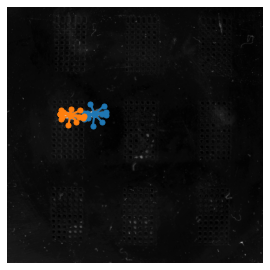

In [6]:
# Visualize a frame.
plot(predictions[100], scale=0.25)

In [7]:
# Inspect the contents of a single frame.
labeled_frame = predictions[100]
labeled_frame.instances

[PredictedInstance(points=[[314.5, 432.5], [348.5, 428.5], [378.5, 426.5], [396.5, 430.5], [394.5, 420.5], [308.5, 446.5], [306.5, 422.5], [342.5, 474.5], [332.5, 386.5], [378.5, 460.5], [388.5, 394.5], [324.5, 442.5], [320.5, 422.5]], track="female", score=0.98, tracking_score=0.56),
 PredictedInstance(points=[[212.5, 426.5], [252.5, 432.5], [288.5, 440.5], [304.5, 444.5], [306.5, 436.5], [216.5, 446.5], [216.5, 410.5], [244.5, 472.5], [256.5, 408.5], [276.5, 458.5], [292.5, 412.5], [220.5, 438.5], [224.5, 418.5]], track="male", score=0.96, tracking_score=0.44)]

In [8]:
# Convert an instance to a numpy array:
labeled_frame[0].numpy()

array([[314.5, 432.5],
       [348.5, 428.5],
       [378.5, 426.5],
       [396.5, 430.5],
       [394.5, 420.5],
       [308.5, 446.5],
       [306.5, 422.5],
       [342.5, 474.5],
       [332.5, 386.5],
       [378.5, 460.5],
       [388.5, 394.5],
       [324.5, 442.5],
       [320.5, 422.5]])